In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

c:\Users\Arya\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [3]:
IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=3
EPOCHS=50

In [4]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [5]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
len(dataset)

68

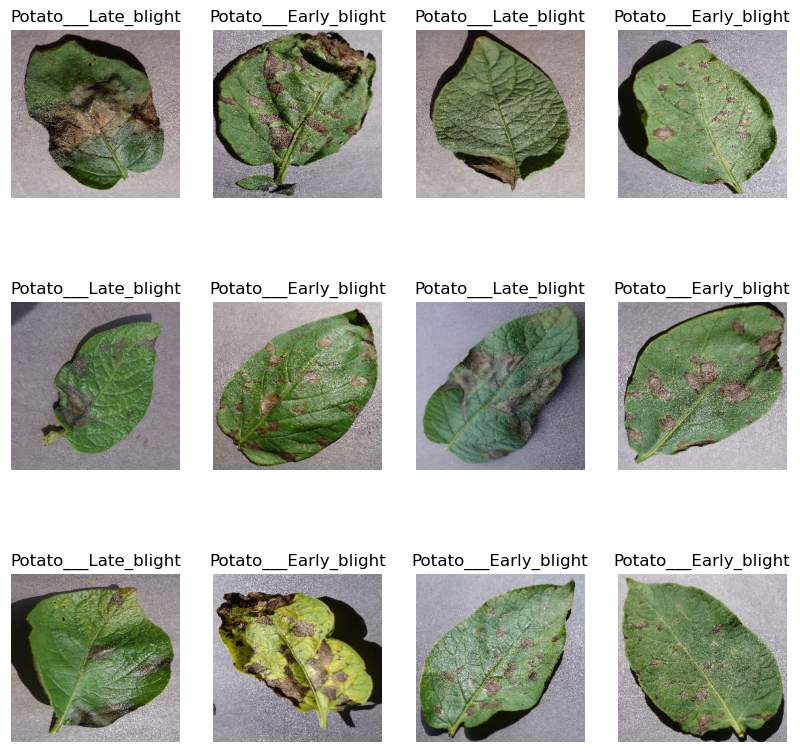

In [7]:
plt.figure(figsize=(10,10))
for images,label in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(class_names[label[i]])

In [8]:
train_size=0.8
len(dataset)*train_size

54.400000000000006

In [9]:
train_ds=dataset.take(54)
len(train_ds)

54

In [10]:
test_ds=dataset.skip(54)
len(test_ds)

14

In [11]:
val_size=0.1
len(dataset)*val_size

6.800000000000001

In [12]:
val_ds=test_ds.take(6)
len(val_ds)

6

In [13]:
test_ds=test_ds.skip(6)
len(test_ds)

8

In [14]:
def get_dataset_partitions_tf(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):
    ds_size=len(ds)
    if(shuffle):
        ds=ds.shuffle(shuffle_size,seed=12)
    
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)

    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)

    return train_ds,val_ds,test_ds

In [15]:
train_ds,val_ds,test_ds=get_dataset_partitions_tf(dataset)

In [16]:
len(train_ds)

54

In [17]:
len(test_ds)

8

In [18]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [19]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [21]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes=3
model = models.Sequential([

    # Preprocessing
    resize_and_rescale,
    data_augmentation,

    # CNN Block 1
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
    ),
    layers.MaxPooling2D((2,2)),

    # CNN Block 2
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    layers.MaxPooling2D((2,2)),

    # CNN Block 3
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    layers.MaxPooling2D((2,2)),

    # Convert feature maps to vector
    layers.Flatten(),

    # Dense Layer
    layers.Dense(
        64,
        activation='relu'
    ),

    # Output Layer
    layers.Dense(
        n_classes,
        activation='softmax'
    )
])

model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))

model.summary()
    

c:\Users\Arya\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,742,979 (14.28 MB)

 Trainable params: 3,742,979 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history=model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE, 
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 396ms/step - accuracy: 0.7251 - loss: 0.6662 - val_accuracy: 0.8125 - val_loss: 0.5076
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 374ms/step - accuracy: 0.8663 - loss: 0.3594 - val_accuracy: 0.8750 - val_loss: 0.3745
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 384ms/step - accuracy: 0.8762 - loss: 0.3362 - val_accuracy: 0.7969 - val_loss: 0.5165
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 381ms/step - accuracy: 0.9022 - loss: 0.2520 - val_accuracy: 0.9219 - val_loss: 0.2560
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 374ms/step - accuracy: 0.9259 - loss: 0.2064 - val_accuracy: 0.8333 - val_loss: 0.4195
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 374ms/step - accuracy: 0.9190 - loss: 0.2337 - val_accuracy: 0.8698 - val_loss: 0.3213
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 372ms/step - accuracy: 0.9468 - loss: 0.1456 - val_accuracy: 0.9219 - val_loss: 0.2422
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 373ms/step - accuracy: 0.9456 - loss: 0.1508 - val_accu

In [24]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.9688 - loss: 0.0795


In [25]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']

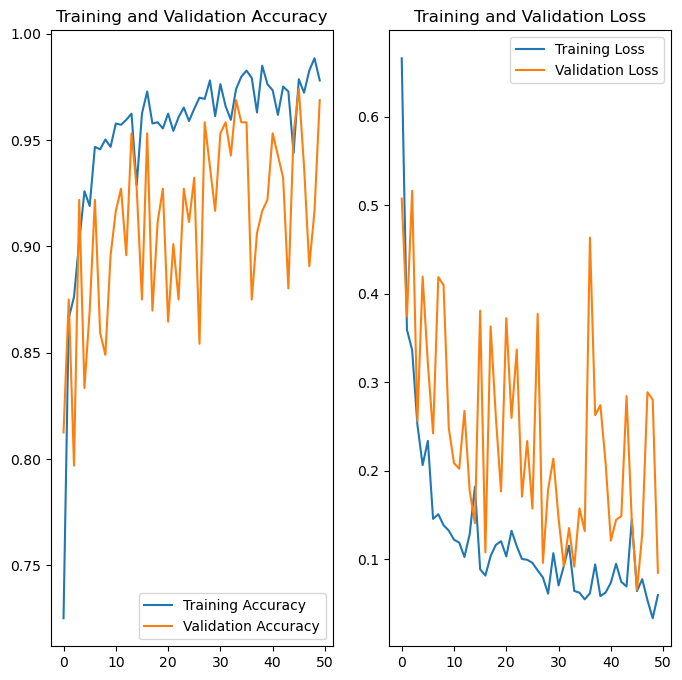

In [26]:
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)

plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')

plt.legend(loc='lower right')

plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)

plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')

plt.legend(loc='upper right')

plt.title('Training and Validation Loss')

plt.show()

First image to predict
Actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1


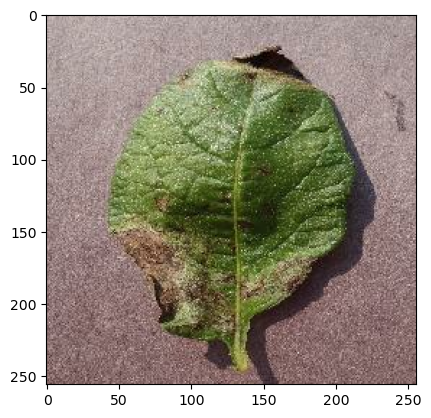

In [27]:
import numpy as np

for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("First image to predict")
    plt.imshow(first_image)
    print("Actual label:", class_names[first_label])

    batch_prediction = model.predict(images_batch)

    print(np.argmax(batch_prediction[0]))

In [28]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


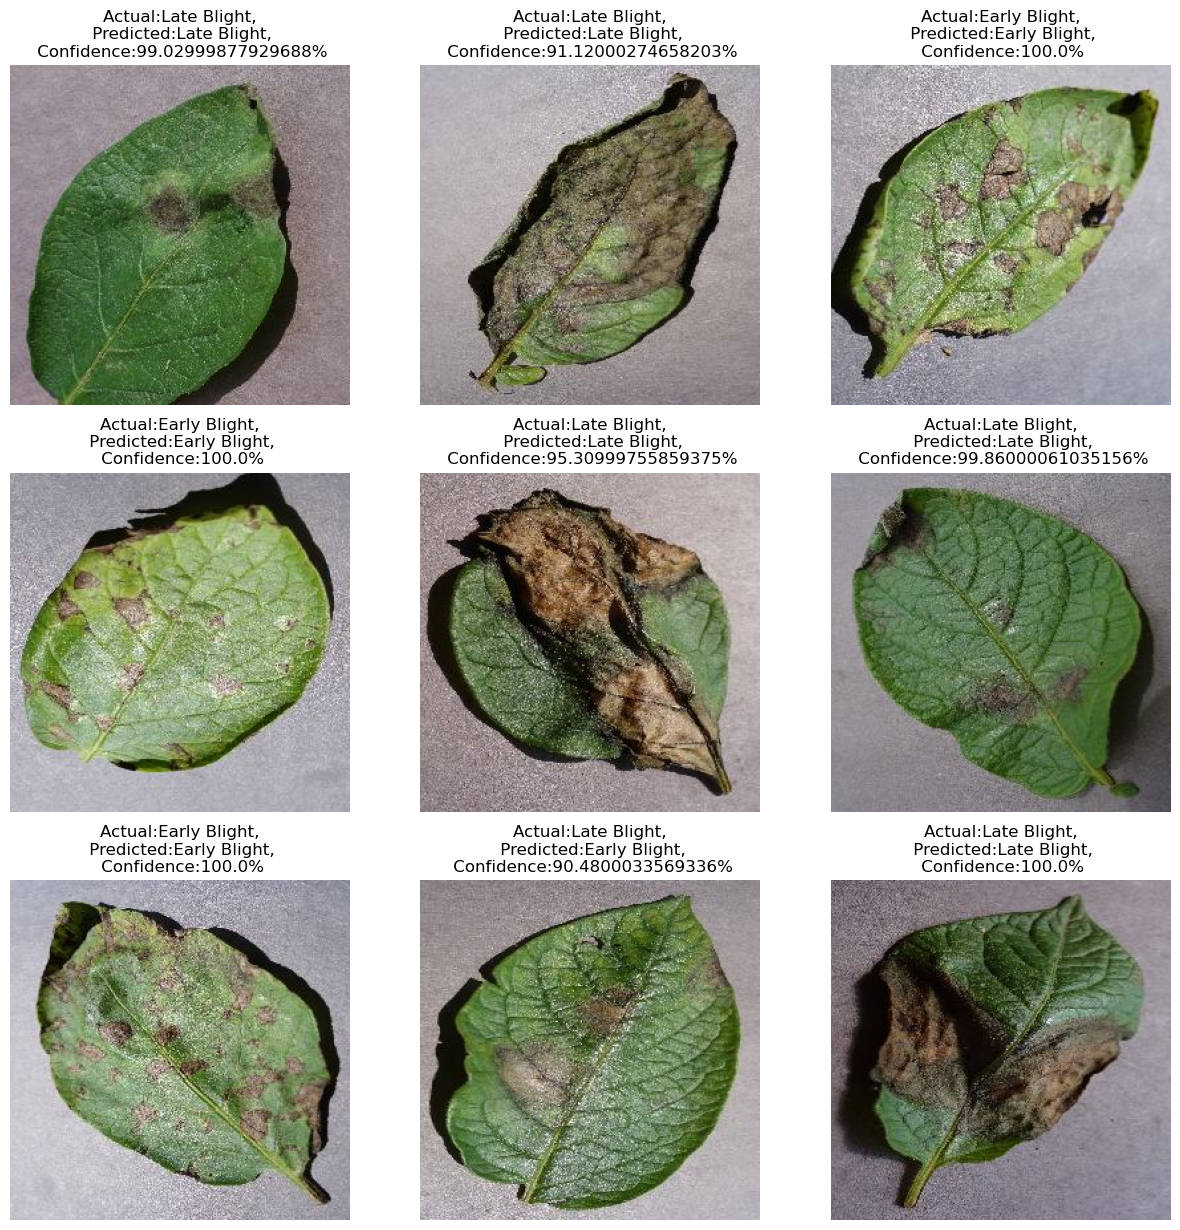

In [92]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f"Actual:{actual_class},\n Predicted:{predicted_class},\n Confidence:{confidence}%")
        plt.axis("off")

In [30]:
model_version = 1
model.save(f"../models/{model_version}.keras")

In [31]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [32]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [33]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                       precision    recall  f1-score   support

Potato___Early_blight       0.97      1.00      0.98       119
 Potato___Late_blight       1.00      0.93      0.97       122
     Potato___healthy       0.79      1.00      0.88        15

             accuracy                           0.97       256
            macro avg       0.92      0.98      0.94       256
         weighted avg       0.97      0.97      0.97       256



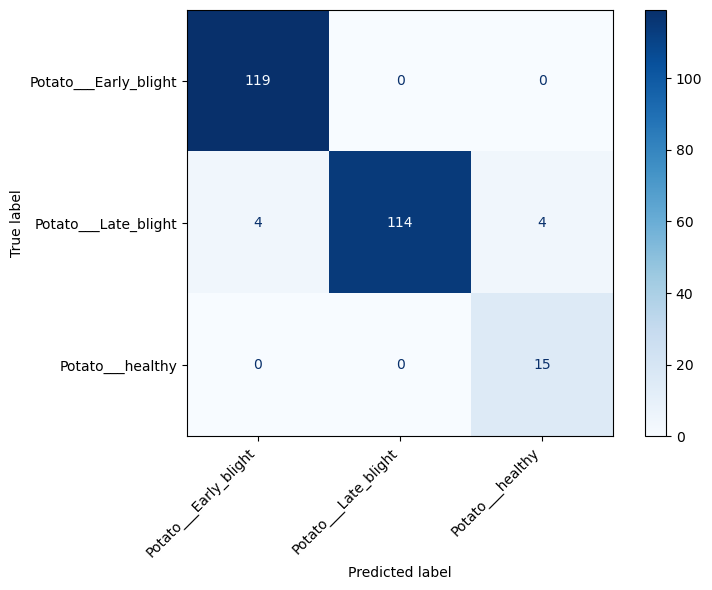

<Figure size 640x480 with 0 Axes>

In [34]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", ax=ax)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()
plt.savefig("hm.png")

In [35]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [47]:
image = cv2.imread("test.JPG")
image = cv2.resize(image, (256,256))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# DO NOT divide by 255
img_array = np.expand_dims(image_rgb.astype(np.float32), axis=0)

In [48]:
preds = model.predict(img_array)
pred_index = np.argmax(preds[0])

class_names = [
    "Early Blight",
    "Late Blight",
    "Healthy"
]

print("Prediction:", class_names[pred_index])
print("Confidence:", np.max(preds[0]) * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction: Early Blight
Confidence: 99.14077


In [70]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Return a Grad-CAM heatmap for a single image batch."""
    x = np.asarray(img_array)
    if x.ndim == 3:
        x = np.expand_dims(x, axis=0)

    x = tf.convert_to_tensor(x, dtype=tf.float32)

    input_tensor = tf.keras.Input(shape=x.shape[1:], dtype=tf.float32, name="input_image")
    current = input_tensor
    target_output = None

    for layer in model.layers:
        current = layer(current, training=False)
        if layer.name == last_conv_layer_name:
            target_output = current

    if target_output is None:
        raise ValueError(f"Layer '{last_conv_layer_name}' not found in model")

    grad_model = tf.keras.Model(inputs=input_tensor, outputs=[target_output, current])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(x, training=False)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0.0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)

    return heatmap[0].numpy()


In [71]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    "conv2d_2"
)


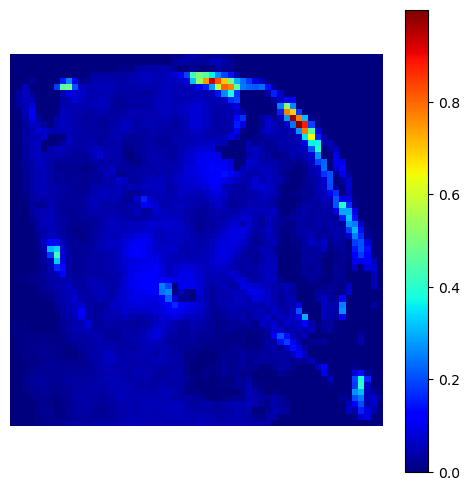

In [72]:
plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.axis("off")
plt.show()


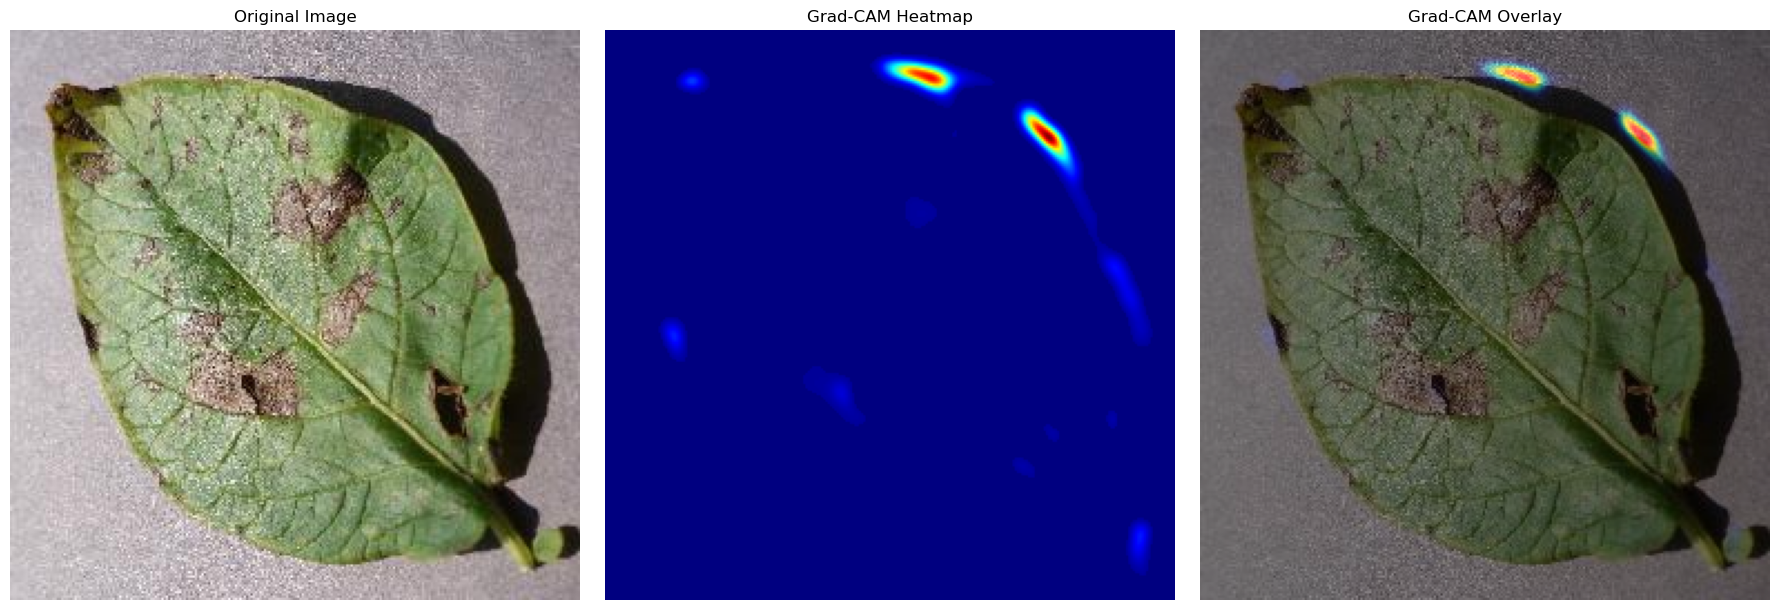

In [75]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Resize heatmap to the original image size
heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
heatmap_resized = cv2.GaussianBlur(heatmap_resized, (15, 15), 0)

# Normalize and sharpen strong activations
heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (
    heatmap_resized.max() - heatmap_resized.min() + 1e-8
)
heatmap_resized = np.power(heatmap_resized, 2.0)

# Keep the strongest 5% of responses for a more obvious overlay
p95 = np.percentile(heatmap_resized, 95)
heatmap_mask = np.where(heatmap_resized >= p95, heatmap_resized, 0.0)

# Convert to color map for the overlay
heatmap_uint8 = np.uint8(255 * heatmap_mask)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Stronger overlay for better visibility
overlay = image_rgb.astype(np.float32) * 0.55
overlay += heatmap_color.astype(np.float32) * 0.95 * heatmap_mask[..., None]
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_color)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


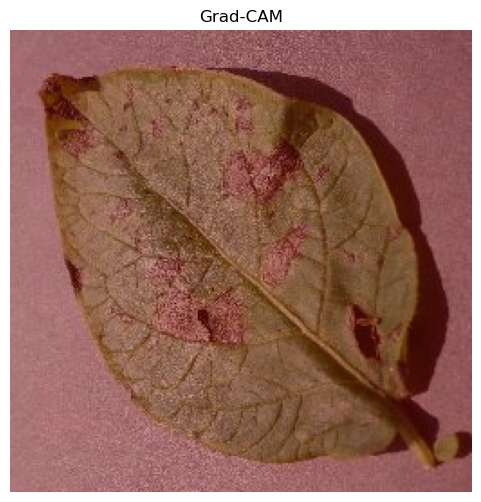

In [ ]:
# Compact overlay with stronger visibility
heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
heatmap_resized = cv2.GaussianBlur(heatmap_resized, (15, 15), 0)
heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (
    heatmap_resized.max() - heatmap_resized.min() + 1e-8
)
heatmap_resized = np.power(heatmap_resized, 2.0)
p95 = np.percentile(heatmap_resized, 95)
heatmap_mask = np.where(heatmap_resized >= p95, heatmap_resized, 0.0)
heatmap_uint8 = np.uint8(255 * heatmap_mask)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

overlay = image_rgb.astype(np.float32) * 0.55
overlay += heatmap_color.astype(np.float32) * 0.95 * heatmap_mask[..., None]
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM")
plt.show()


In [76]:
import cv2
import numpy as np

image = cv2.imread("test.JPG")
image = cv2.resize(image, (256,256))

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

In [77]:
lower = np.array([5, 40, 20])
upper = np.array([35, 255, 255])

mask = cv2.inRange(hsv, lower, upper)

In [78]:
disease_pixels = np.count_nonzero(mask)
total_pixels = mask.size

severity = (disease_pixels / total_pixels) * 100

print(f"Disease Severity: {severity:.2f}%")

Disease Severity: 19.00%


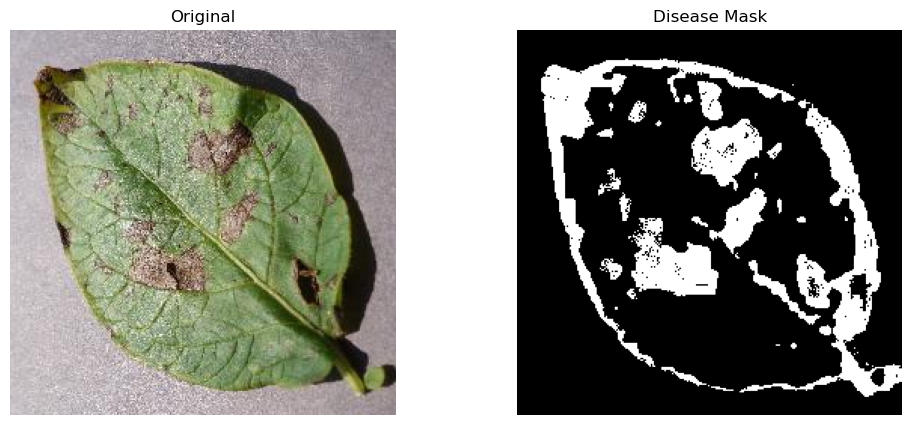

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Disease Mask")
plt.axis("off")

plt.show()

In [80]:
if severity < 10:
    level = "Healthy / Very Mild"
elif severity < 30:
    level = "Mild"
elif severity < 60:
    level = "Moderate"
else:
    level = "Severe"

print(level)

Mild


In [88]:
# ==============================
# Disease Name Mapping
# ==============================

display_name = {
    "Potato___Early_blight": "Early Blight",
    "Potato___Late_blight": "Late Blight",
    "Potato___healthy": "Healthy"
}

# ==============================
# Treatment Database
# ==============================

treatment = {

    "Potato___Early_blight": {

        "medicine": "Mancozeb",

        "dosage": "2.5 g/L",

        "steps": [
            "Remove infected leaves.",
            "Spray Mancozeb every 7 days.",
            "Avoid overwatering.",
            "Ensure good air circulation.",
            "Monitor plants regularly."
        ]
    },

    "Potato___Late_blight": {

        "medicine": "Metalaxyl + Mancozeb",

        "dosage": "2.5 g/L",

        "steps": [
            "Remove severely infected plants.",
            "Spray Metalaxyl + Mancozeb immediately.",
            "Avoid overhead irrigation.",
            "Improve field drainage.",
            "Monitor disease spread daily."
        ]
    },

    "Potato___healthy": {

        "medicine": "None",

        "dosage": "-",

        "steps": [
            "Plant is healthy.",
            "Continue regular monitoring.",
            "Maintain proper irrigation.",
            "Use balanced fertilizer.",
            "Inspect leaves weekly."
        ]
    }

}

# ==============================
# Prediction Result
# ==============================

prediction = predicted_class

info = treatment[prediction]

print("="*50)
print("🌿 AI Potato Disease Detection Report")
print("="*50)

print(f"Disease Detected : {display_name[prediction]}")
print(f"Medicine         : {info['medicine']}")
print(f"Dosage           : {info['dosage']}")

# If you already calculated severity
try:
    print(f"Severity         : {severity:.2f}%")
except NameError:
    pass

print("\nRecommended Treatment:")

for i, step in enumerate(info["steps"], start=1):
    print(f"{i}. {step}")

print("="*50)

🌿 AI Potato Disease Detection Report
Disease Detected : Healthy
Medicine         : None
Dosage           : -
Severity         : 19.00%

Recommended Treatment:
1. Plant is healthy.
2. Continue regular monitoring.
3. Maintain proper irrigation.
4. Use balanced fertilizer.
5. Inspect leaves weekly.


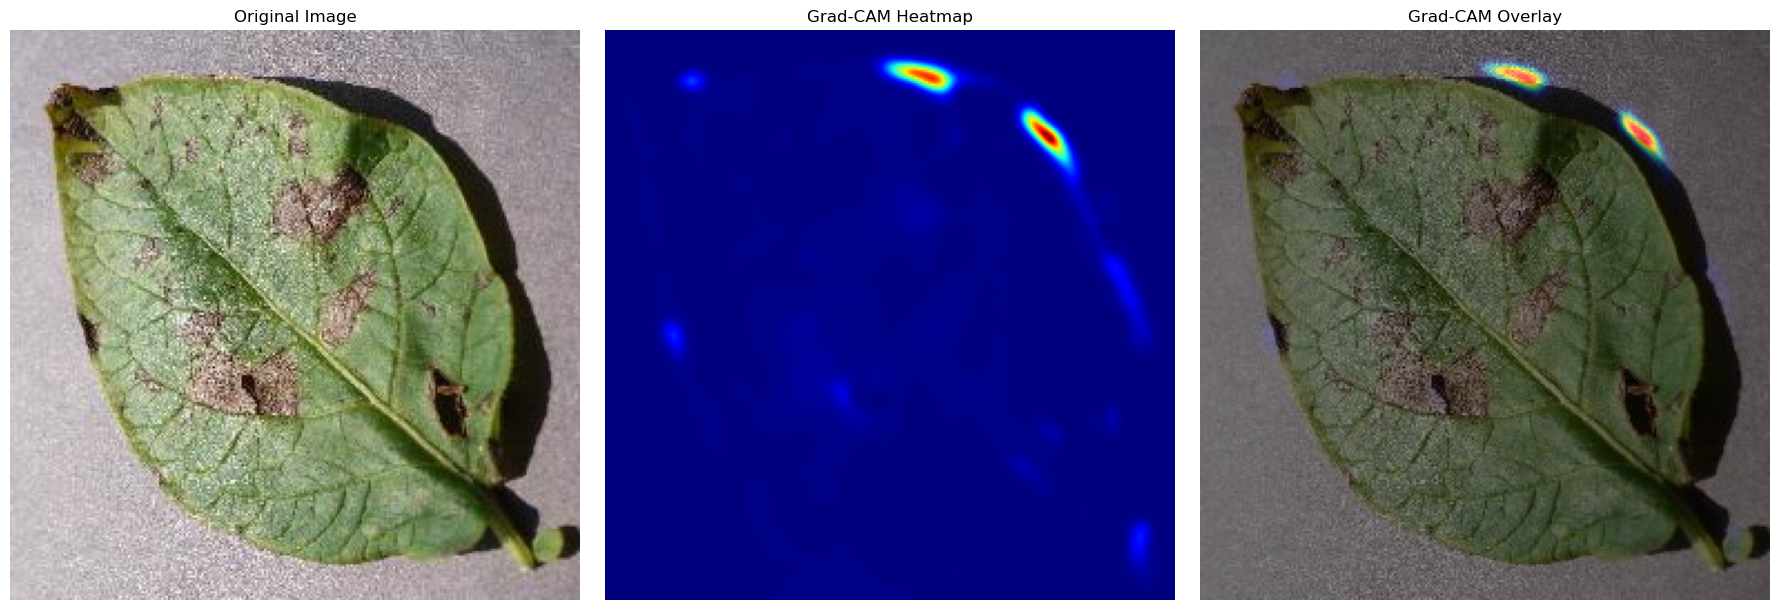

AI Potato Disease Detection Report
Disease          : Early Blight
Confidence       : 99.14%
Severity         : 19.00% (Mild)
Medicine         : Mancozeb
Dosage           : 2.5 g/L

Recommended Treatment:
1. Remove infected leaves.
2. Spray Mancozeb every 7 days.
3. Avoid overwatering.
4. Ensure good air circulation.
5. Monitor plants regularly.


{'prediction': 'Early Blight',
 'confidence': np.float32(99.14),
 'severity': 19.0,
 'severity_level': 'Mild',
 'medicine': 'Mancozeb',
 'dosage': '2.5 g/L',
 'steps': ['Remove infected leaves.',
  'Spray Mancozeb every 7 days.',
  'Avoid overwatering.',
  'Ensure good air circulation.',
  'Monitor plants regularly.'],
 'overlay': array([[[ 97,  94,  98],
         [ 96,  94,  97],
         [ 98,  95,  99],
         ...,
         [ 78,  74,  78],
         [ 74,  70,  74],
         [ 70,  66,  70]],
 
        [[101,  98, 102],
         [100,  97, 101],
         [101,  98, 102],
         ...,
         [ 78,  74,  78],
         [ 75,  71,  75],
         [ 70,  67,  70]],
 
        [[102, 100, 103],
         [102,  99, 103],
         [102, 100, 103],
         ...,
         [ 78,  74,  78],
         [ 76,  72,  76],
         [ 73,  69,  73]],
 
        ...,
 
        [[113, 110, 112],
         [114, 111, 113],
         [113, 110, 112],
         ...,
         [ 80,  74,  76],
         [ 81,  

In [97]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


def load_image(image_path):
    """Load an image from a file path or uploaded file object."""
    if hasattr(image_path, "read"):
        image_bytes = image_path.read()
        if isinstance(image_bytes, str):
            image_bytes = image_bytes.encode("utf-8")

        nparr = np.frombuffer(image_bytes, np.uint8)
        image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        if image is None:
            raise ValueError("Unable to read the uploaded image.")
    else:
        image_path = os.fspath(image_path)
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image not found: {image_path}")

        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Unable to read the image: {image_path}")

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_rgb = cv2.resize(image_rgb, (IMAGE_SIZE, IMAGE_SIZE))
    img_array = np.expand_dims(image_rgb.astype(np.float32), axis=0)

    return image, image_rgb, img_array


def predict_image(img_array):
    """Predict the disease class and confidence for a preprocessed image array."""
    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence


def make_gradcam(image_rgb, img_array, model, last_conv_layer_name="conv2d_2"):
    """Generate a Grad-CAM heatmap and overlay for the input image."""
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
    heatmap_resized = cv2.GaussianBlur(heatmap_resized, (15, 15), 0)
    heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (
        heatmap_resized.max() - heatmap_resized.min() + 1e-8
    )
    heatmap_resized = np.power(heatmap_resized, 2.0)

    p95 = np.percentile(heatmap_resized, 95)
    heatmap_mask = np.where(heatmap_resized >= p95, heatmap_resized, 0.0)

    heatmap_uint8 = np.uint8(255 * heatmap_mask)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = image_rgb.astype(np.float32) * 0.55
    overlay += heatmap_color.astype(np.float32) * 0.95 * heatmap_mask[..., None]
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    return heatmap_resized, overlay


def estimate_severity(image_rgb):
    """Estimate disease severity from the input image using HSV thresholds."""
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    lower = np.array([5, 40, 20])
    upper = np.array([35, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)

    disease_pixels = np.count_nonzero(mask)
    total_pixels = mask.size
    severity_percentage = round((disease_pixels / total_pixels) * 100, 2)

    if severity_percentage < 10:
        severity_level = "Healthy / Very Mild"
    elif severity_percentage < 30:
        severity_level = "Mild"
    elif severity_percentage < 60:
        severity_level = "Moderate"
    else:
        severity_level = "Severe"

    return severity_percentage, severity_level


def recommend_treatment(predicted_class, language="English"):
    """
    Return treatment information for a predicted disease class
    in the selected language.
    """

    treatment_dict = recommendations.get(language, recommendations["English"])

    if predicted_class in treatment_dict:
        info = treatment_dict[predicted_class]
    else:
        display_mapping = globals().get("display_name", {})
        predicted_key = next(
            (key for key, value in display_mapping.items() if value == predicted_class),
            predicted_class,
        )
        info = treatment_dict[predicted_key]

    return info["medicine"], info["dosage"], info["steps"]


def display_results(
    image_rgb,
    heatmap,
    overlay,
    predicted_class,
    confidence,
    severity_percentage,
    severity_level,
    medicine,
    dosage,
    steps,
):
    """Display the original image, Grad-CAM heatmap, overlay and report details."""
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    display_mapping = globals().get("display_name", {})
    disease_name = display_mapping.get(predicted_class, predicted_class)

    print("=" * 50)
    print("AI Potato Disease Detection Report")
    print("=" * 50)
    print(f"Disease          : {disease_name}")
    print(f"Confidence       : {confidence:.2f}%")
    print(f"Severity         : {severity_percentage:.2f}% ({severity_level})")
    print(f"Medicine         : {medicine}")
    print(f"Dosage           : {dosage}")
    print("\nRecommended Treatment:")
    for i, step in enumerate(steps, start=1):
        print(f"{i}. {step}")
    print("=" * 50)


def predict_leaf(image_path,language="English"):
    """Run the full inference pipeline for a single leaf image."""
    _, image_rgb, img_array = load_image(image_path)
    predicted_class, confidence = predict_image(img_array)
    heatmap, overlay = make_gradcam(image_rgb, img_array, model)
    severity_percentage, severity_level = estimate_severity(image_rgb)
    medicine, dosage, steps = recommend_treatment(predicted_class,language)


    display_results(
        image_rgb,
        heatmap,
        overlay,
        predicted_class,
        confidence,
        severity_percentage,
        severity_level,
        medicine,
        dosage,
        steps,
    )
    cv2.imwrite(
    "prediction_overlay.png",
    cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))


    return {
        "prediction": predicted_class,
        "confidence": confidence,
        "severity": severity_percentage,
        "severity_level": severity_level,
        "medicine": medicine,
        "dosage": dosage,
        "steps": steps,
        "overlay": overlay,
        "heatmap": heatmap,
    }



# Example usage
result = predict_leaf("test.JPG")
result


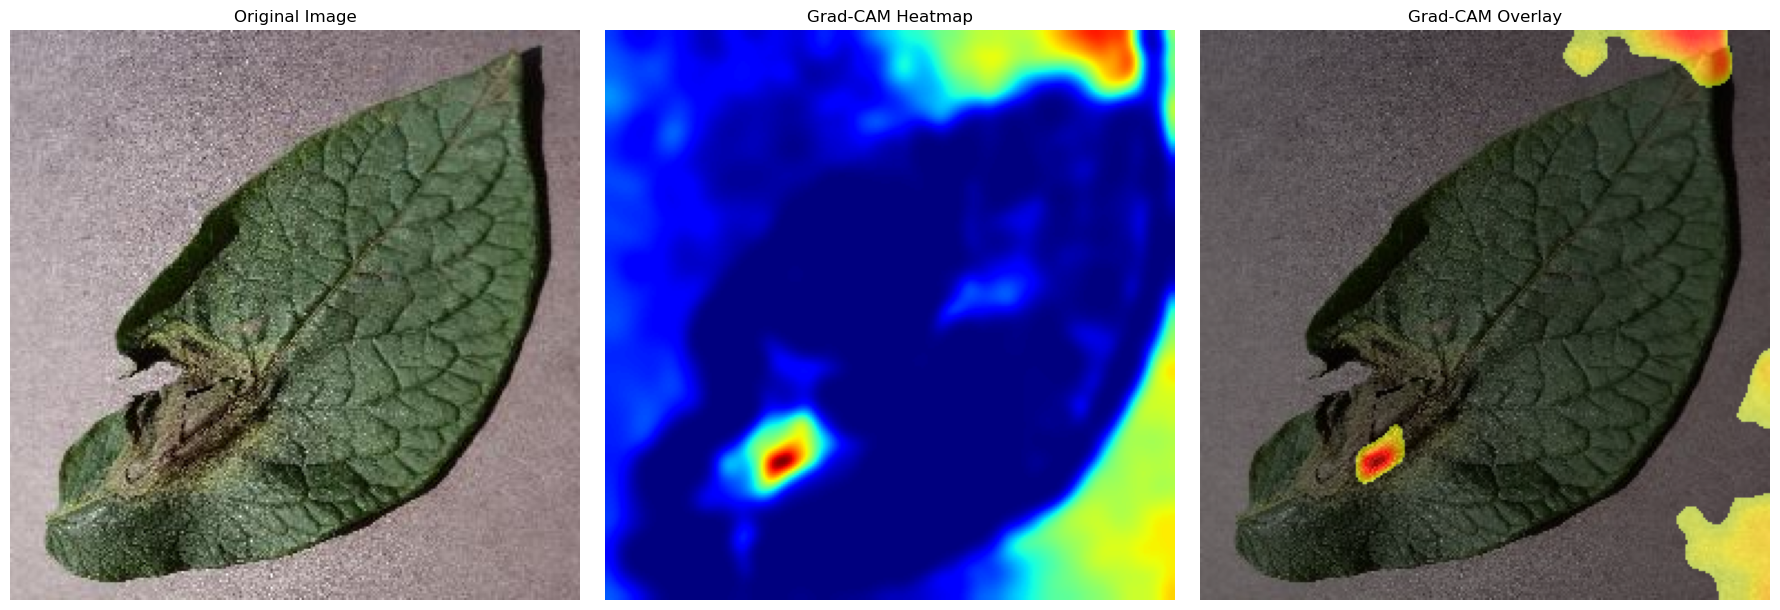

AI Potato Disease Detection Report
Disease          : Late Blight
Confidence       : 91.30%
Severity         : 7.63% (Healthy / Very Mild)
Medicine         : मेटालैक्सिल + मैनकोजेब
Dosage           : 2.5 ग्राम/लीटर

Recommended Treatment:
1. संक्रमित पौधों को हटाएँ।
2. तुरंत स्प्रे करें।
3. ऊपर से सिंचाई न करें।
4. जल निकासी सुधारें।
5. प्रतिदिन निगरानी करें।


{'prediction': 'Late Blight',
 'confidence': np.float32(91.3),
 'severity': 7.63,
 'severity_level': 'Healthy / Very Mild',
 'medicine': 'मेटालैक्सिल + मैनकोजेब',
 'dosage': '2.5 ग्राम/लीटर',
 'steps': ['संक्रमित पौधों को हटाएँ।',
  'तुरंत स्प्रे करें।',
  'ऊपर से सिंचाई न करें।',
  'जल निकासी सुधारें।',
  'प्रतिदिन निगरानी करें।'],
 'overlay': array([[[ 91,  85,  90],
         [ 86,  80,  84],
         [ 89,  83,  87],
         ...,
         [ 67,  58,  61],
         [ 62,  53,  56],
         [ 57,  48,  51]],
 
        [[ 91,  85,  90],
         [ 85,  79,  84],
         [ 87,  81,  85],
         ...,
         [ 72,  63,  66],
         [ 69,  61,  63],
         [ 65,  57,  59]],
 
        [[ 85,  79,  84],
         [ 79,  73,  78],
         [ 83,  77,  81],
         ...,
         [ 72,  64,  67],
         [ 72,  64,  67],
         [ 70,  62,  64]],
 
        ...,
 
        [[105,  99,  99],
         [103,  97,  97],
         [103,  97,  97],
         ...,
         [245, 199,  70],
  

In [104]:
image_path = "../test_images/late.JPG"

if not os.path.exists(image_path):
    raise FileNotFoundError(
        f"Image not found: {image_path}. "
        "Please place the image in that folder or update the path."
    )

result = predict_leaf(image_path, language="Hindi")
result

In [96]:
recommendations = {

    "English": {

        "Potato___Early_blight": {
            "medicine": "Mancozeb",
            "dosage": "2.5 g/L",
            "steps": [
                "Remove infected leaves.",
                "Spray Mancozeb every 7 days.",
                "Avoid overwatering.",
                "Ensure good air circulation.",
                "Monitor plants regularly."
            ]
        },

        "Potato___Late_blight": {
            "medicine": "Metalaxyl + Mancozeb",
            "dosage": "2.5 g/L",
            "steps": [
                "Remove severely infected plants.",
                "Spray immediately.",
                "Avoid overhead irrigation.",
                "Improve field drainage.",
                "Monitor disease spread daily."
            ]
        },

        "Potato___healthy": {
            "medicine": "None",
            "dosage": "-",
            "steps": [
                "Plant is healthy.",
                "Continue regular monitoring.",
                "Maintain proper irrigation.",
                "Inspect leaves weekly."
            ]
        }

    },

    "Hindi": {

        "Potato___Early_blight": {
            "medicine": "मैनकोजेब",
            "dosage": "2.5 ग्राम/लीटर",
            "steps": [
                "संक्रमित पत्तियाँ हटाएँ।",
                "हर 7 दिन में स्प्रे करें।",
                "अधिक पानी देने से बचें।",
                "हवा का अच्छा प्रवाह बनाए रखें।",
                "पौधों की नियमित जांच करें।"
            ]
        },

        "Potato___Late_blight": {
            "medicine": "मेटालैक्सिल + मैनकोजेब",
            "dosage": "2.5 ग्राम/लीटर",
            "steps": [
                "संक्रमित पौधों को हटाएँ।",
                "तुरंत स्प्रे करें।",
                "ऊपर से सिंचाई न करें।",
                "जल निकासी सुधारें।",
                "प्रतिदिन निगरानी करें।"
            ]
        },

        "Potato___healthy": {
            "medicine": "कोई दवा नहीं",
            "dosage": "-",
            "steps": [
                "पौधा स्वस्थ है।",
                "नियमित निगरानी करें।",
                "संतुलित सिंचाई बनाए रखें।",
                "साप्ताहिक निरीक्षण करें।"
            ]
        }

    }

}